In [ ]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
zip_path = "/content/drive/MyDrive/dlproject/plantVillage.zip"

In [ ]:
with zipfile.ZipFile(zip_path,'r') as zip_ref:
  zip_ref.extractall("/content/dataset")

In [ ]:
IMAGE_SIZE = 128
BATCH_SIZE = 16
CHANNELS =3
EPOCHS =50

In [ ]:
!ls /content

dataset  drive	sample_data


In [ ]:
!find /content -type d | grep PlantVillage

/content/dataset/PlantVillage
/content/dataset/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite
/content/dataset/PlantVillage/Tomato_Septoria_leaf_spot
/content/dataset/PlantVillage/Pepper__bell___Bacterial_spot
/content/dataset/PlantVillage/Tomato__Tomato_mosaic_virus
/content/dataset/PlantVillage/Tomato_healthy
/content/dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
/content/dataset/PlantVillage/Tomato_Early_blight
/content/dataset/PlantVillage/Potato___Early_blight
/content/dataset/PlantVillage/Tomato_Leaf_Mold
/content/dataset/PlantVillage/Pepper__bell___healthy
/content/dataset/PlantVillage/Tomato__Target_Spot
/content/dataset/PlantVillage/Potato___Late_blight
/content/dataset/PlantVillage/Tomato_Bacterial_spot
/content/dataset/PlantVillage/Tomato_Late_blight
/content/dataset/PlantVillage/Potato___healthy


In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset/PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.


In [ ]:
class_names = dataset.class_names
class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

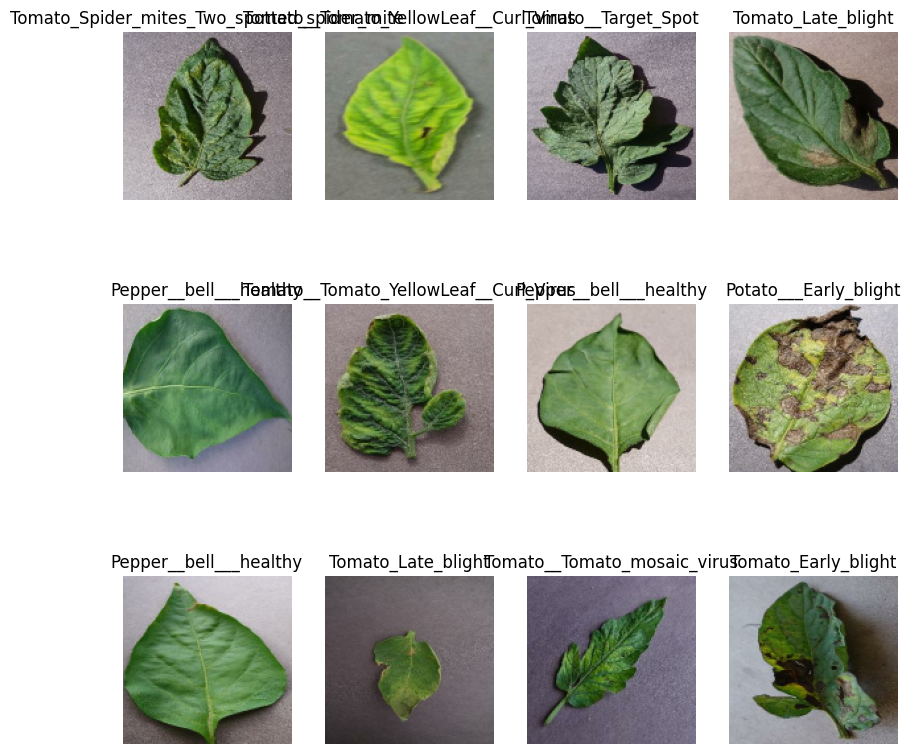

In [ ]:
plt.figure(figsize=(10,10))
for image_batch,labels_batch in dataset.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[labels_batch[i]])
    plt.axis("off")

In [ ]:
len(dataset)

1290

In [ ]:
train_size = 0.8
len(dataset)*train_size

1032.0

In [ ]:
train_ds = dataset.take(1032)
len(train_ds)

1032

In [ ]:
test_ds = dataset.skip(1032)
len(test_ds)

258

In [ ]:
val_size = 0.1
len(dataset)*val_size

129.0

In [ ]:
val_ds = test_ds.take(129)
len(val_ds)

129

In [ ]:
test_ds = test_ds.skip(129)
len(test_ds)

129

In [ ]:
def get_dataset_partition_tf(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):
  ds_size = len(ds)

  if shuffle:
    ds = ds.shuffle(shuffle_size,seed=12)

  train_size = int(train_split*ds_size)
  val_size=int(val_split*ds_size)

  train_ds = ds.take(train_size)
  val_ds = ds.skip(train_size).take(val_size)
  test_ds = ds.skip(train_size).skip(val_size)

  return train_ds,test_ds,val_ds

In [ ]:
train_ds,test_ds,val_ds = get_dataset_partition_tf(dataset)

In [ ]:
len(train_ds)

1032

In [ ]:
len(test_ds)

129

In [ ]:
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [ ]:
input_shape = (BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes = 15

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax')
])

model.build(input_shape=input_shape)

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (16, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (16, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (16, 126, 126, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (16, 63, 63, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (16, 61, 61, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (16, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (16, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (16, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (16, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (16, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (16, 2304)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (16, 64)               │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (16, 15)               │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,743 (944.31 KB)

 Trainable params: 241,743 (944.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,batch_size=BATCH_SIZE,validation_data=val_ds,verbose=1,epochs=EPOCHS)

Epoch 1/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.3907 - loss: 1.8597 - val_accuracy: 0.6085 - val_loss: 1.1920
Epoch 2/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.6651 - loss: 0.9890 - val_accuracy: 0.7182 - val_loss: 0.7608
Epoch 3/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.7543 - loss: 0.7114 - val_accuracy: 0.7035 - val_loss: 0.8882
Epoch 4/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.8073 - loss: 0.5668 - val_accuracy: 0.8222 - val_loss: 0.5511
Epoch 5/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.8348 - loss: 0.4811 - val_accuracy: 0.8566 - val_loss: 0.4181
Epoch 6/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.8591 - loss: 0.4032 - val_accuracy: 0.8920 - val_loss: 0.3052
Epoch 7/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.8749 - loss: 0.3643 - val_accuracy: 0.8886 - val_loss: 0.3318
Epoch 8/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 35s 24ms/step - accuracy: 0.8895 -

In [ ]:
scores = model.evaluate(test_ds)

129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9283 - loss: 0.2577


In [ ]:
scores

[0.25770387053489685, 0.9282945990562439]

In [ ]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 1032}

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

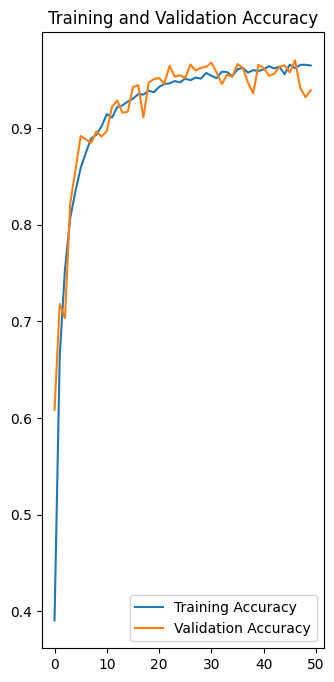

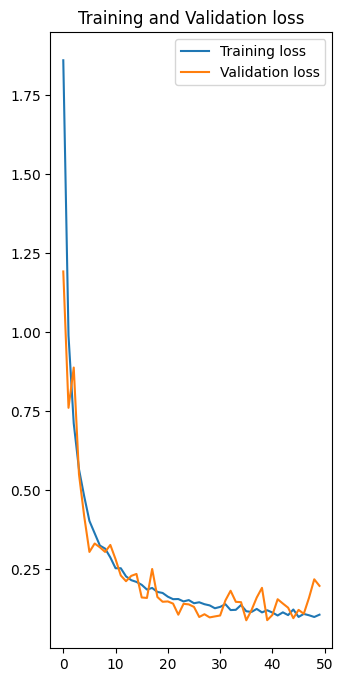

In [ ]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label='Training Accuracy')
plt.plot(range(EPOCHS),val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),loss,label='Training loss')
plt.plot(range(EPOCHS),val_loss,label='Validation loss')
plt.legend(loc='upper right')
plt.title('Training and Validation loss')
plt.show()

first image to predict
actual label: Tomato_Bacterial_spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
predicted label: Tomato_Bacterial_spot


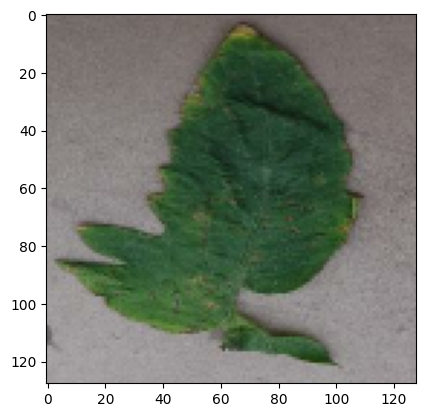

In [ ]:
import numpy as np
for image_batch,labels_batch in test_ds.take(1):
  first_image = image_batch[0].numpy().astype('uint8')
  first_label = labels_batch[0].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  print("actual label:",class_names[first_label])

  batch_prediction = model.predict(image_batch)
  print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [ ]:
def predict(model,img):
  img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array = tf.expand_dims(img_array,0) #create a batch

  predictions = model.predict(img_array)

  predicted_class = class_names[np.argmax(predictions[0])]
  confidence = round(100*(np.max(predictions[0])),2)
  return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


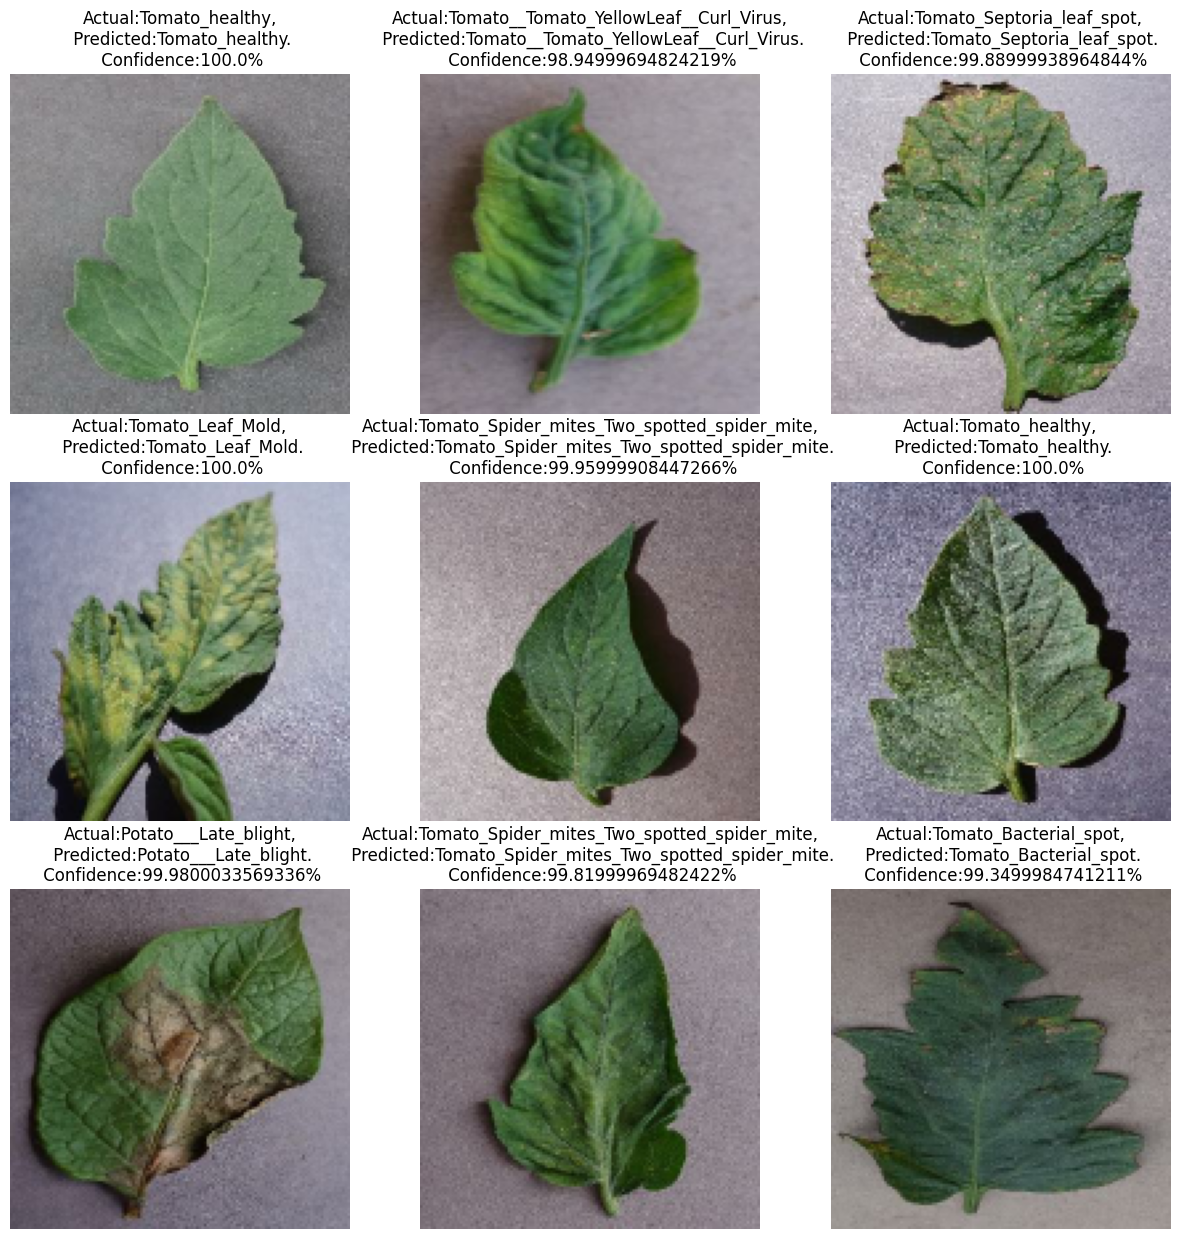

In [ ]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))

    predicted_class,confidence = predict(model,images[i].numpy())
    actual_class = class_names[labels[i]]

    plt.title(f"Actual:{actual_class},\n Predicted:{predicted_class}.\n Confidence:{confidence}%")

    plt.axis('off')

In [ ]:
model.export("saved_model_plantvillage")

Saved artifact at 'saved_model_plantvillage'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_24')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  134077420567440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134077370976016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134077370988880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134077370989648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134077370989456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134077370987728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134077370990224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134077370988304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134077370989072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134077370988112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13

In [ ]:
!zip -r saved_model_plantvillage.zip saved_model_plantvillage/
from google.colab import files
files.download("saved_model_plantvillage.zip")

  adding: saved_model_plantvillage/ (stored 0%)
  adding: saved_model_plantvillage/saved_model.pb (deflated 87%)
  adding: saved_model_plantvillage/assets/ (stored 0%)
  adding: saved_model_plantvillage/variables/ (stored 0%)
  adding: saved_model_plantvillage/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: saved_model_plantvillage/variables/variables.index (deflated 66%)
  adding: saved_model_plantvillage/.zip (stored 0%)
  adding: saved_model_plantvillage/fingerprint.pb (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("plantvillage_model.keras")

In [ ]:
model.save("plantvillage_model.h5")

In [ ]:
files.download("plantvillage_model.keras")
files.download("plantvillage_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>